### 13-Atom Lennard-Jones Cluster

We use the data and checkpoint  from Klein, et al. 2023 (https://osf.io/srqg7/) and learn a score field alongside it, turning a CNF into a stochastic interpolant and using the same equivariant training strategy described in that work.


### 0. Imports & environment

In [1]:
import sys
import pathlib

import numpy as np
import torch
import scipy.stats
import matplotlib.pyplot as plt
%matplotlib inline


_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break


from eesi.systems.lj13.data import load_ref_data, sample_prior, lj_energy
from eesi.systems.lj13.dynamics import LJ13Dynamics, rk4_sample
from eesi.systems.lj13.ot import equivariant_ot_couple
from eesi.systems.lj13.train import make_si_model, train_si
from eesi.config import AveragingConfig

from eesi import CHECKPOINTS_DIR, DATA_DIR


torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:

@torch.no_grad()
def chunked(fn, x0, size=1000):
    return torch.cat([fn(c) for c in x0.split(size)])
    
    
_IU = torch.triu_indices(13, 13, offset=1)          # the 78 unique pairs

def pair_distances(x):                              # (B,13,3) -> (B*78,) all pair distances
    iu = _IU.to(x.device)
    d = x[:, iu[0]] - x[:, iu[1]]
    return d.pow(2).sum(-1).sqrt().reshape(-1)

def energy(x):                                      # physical (i<j) LJ energy, min = -44.327
    return lj_energy(x, ordered=False)

def smooth(v, k=100):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v



### 1. Datasets & samplers



In [3]:
# only grabbing a sub-sample
n_data = 1_000_000
x1 = load_ref_data(n=n_data,seed=5987).to(device)
print("target dataset:", tuple(x1.shape))

e_ref = chunked(energy,x1,100_000)
print(f"reference energy: <E> = {e_ref.mean():+.3f}   min = {e_ref.min():+.3f} "
      f"(global minimum is -44.327)")

torch.cuda.empty_cache()


target dataset: (1000000, 13, 3)
reference energy: <E> = -26.066   min = -39.367 (global minimum is -44.327)


### 2. Model & checkpoint load

`make_si_model` returns an `LJ13EESI` module wrapping two independent `LJ13Dynamics` E(n)-GNNs, one
for the velocity `b` and one for the score `s`.

The checkpoint is a *flow-matching velocity*, i.e. exactly `b(t,x) = E[x₁ − x₀ | x_t]` for
the noise-free linear interpolant. Switching on the latent noise (`gamma_scale > 0`)
smears the marginals but only slightly, so the checkpoint is a good "warm start" for `net_b`. 
On the other hand, `net_s` starts from scratch.

In [8]:
torch.manual_seed(1)

batch_size=256

model = make_si_model(
    n_particles=13, n_dims=3,
    path="linear", gamma="sqrt", gamma_scale=0.2,
    score_div_method="exact",learn_score=False
).to(device=device, dtype=torch.float64)


# Warm-start the drift from the released OSF equivariant-OT flow-matching checkpoint.
ckpt = LJ13Dynamics.from_checkpoint().to(device=device, dtype=torch.float64)

# warm-start the velocity
model.net_b.load_state_dict(ckpt.state_dict())

# or just load a previously-trained checkpoint
model.net_b.load_state_dict(torch.load( CHECKPOINTS_DIR / "lj13" /  "lj13_b_avg.pth"))
model.net_s.load_state_dict(torch.load(CHECKPOINTS_DIR / "lj13" / "lj13_s_avg.pth"))


<All keys matched successfully>

#### 2.1 Original Checkpoint

In [7]:
torch.seed()
x0_base = sample_prior(5_000, device=device)
# using the same RK4 scheme from the original
gen_ckpt = chunked(lambda c: rk4_sample(ckpt, c, n_steps=50), x0_base)
e_ckpt = energy(gen_ckpt)
print(f"checkpoint (RK4): <E> = {e_ckpt.mean():+.3f}   std = {e_ckpt.std():.3f}")
print(f"reference       : <E> = {e_ref.mean():+.3f}   std = {e_ref.std():.3f}")

checkpoint (RK4): <E> = -25.296   std = 3.072
reference       : <E> = -26.066   std = 2.970


### 3. Training with equivariant OT


In [ ]:
torch.manual_seed(919)

model, htot = train_si(
    x1, model=model, steps=10000, batch=batch_size, lr=1e-3,
    device=str(device), log_every=100, entropy="both")

# EMA over the fine-tune stage only
model, hist = train_si(
    x1, model=model, steps=10000, batch=batch_size, lr=1e-4,
    device=str(device), log_every=100, entropy="both",
    averaging=AveragingConfig(kind="ema", decay=0.999))

htot += hist # combining the histories


hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*htot))
torch.save(model.avg.net_b.state_dict(), CHECKPOINTS_DIR / "lj13" / "lj13_b_avg.pth")
torch.save(model.avg.net_s.state_dict(), CHECKPOINTS_DIR / "lj13" / "lj13_s_avg.pth")
np.save("lj13_hist.npy",np.array(htot))

  step     0  loss_b   -0.1402  loss_s   13.5074  S_dot    4.2719  S_zdot  -33.4258  transport    9.06  (  0.1s)
  step   100  loss_b   -2.1953  loss_s  -67.8777  S_dot  -16.6418  S_zdot  -32.6210  transport    9.55  ( 13.6s)
  step   200  loss_b   -2.2964  loss_s -229.2747  S_dot  -28.4081  S_zdot  -33.6184  transport    9.02  ( 27.1s)
  step   300  loss_b   -2.3337  loss_s -243.5929  S_dot  -28.9738  S_zdot  -33.8197  transport    9.20  ( 40.6s)
  step   400  loss_b   -2.3090  loss_s -244.7406  S_dot  -29.1255  S_zdot  -33.5419  transport    9.04  ( 54.2s)
  step   500  loss_b   -2.3312  loss_s -254.3903  S_dot  -29.6047  S_zdot  -34.0042  transport    9.04  ( 67.7s)
  step   600  loss_b   -2.3342  loss_s -264.5147  S_dot  -30.2618  S_zdot  -34.3811  transport    9.13  ( 81.3s)
  step   700  loss_b   -2.3272  loss_s -253.3716  S_dot  -29.5279  S_zdot  -33.8867  transport    9.09  ( 94.8s)
  step   800  loss_b   -2.3255  loss_s -260.8982  S_dot  -30.1549  S_zdot  -34.0022  transport  

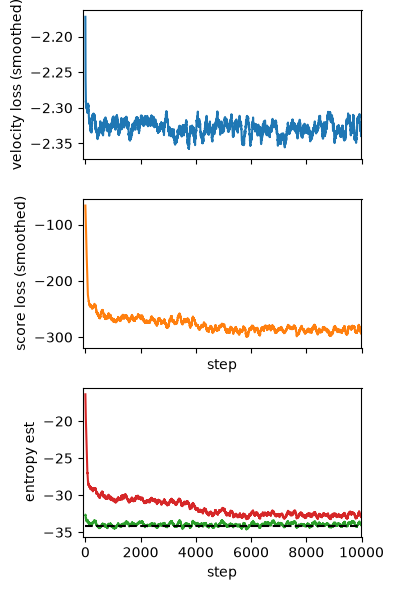

In [9]:
htot = np.load("lj13_hist.npy")
hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*htot))
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(4, 6))
ax[0].plot(smooth(hist_b,100), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s,100), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
ax[2].plot(smooth(ent_zdot,100), "-C2")
ax[2].plot(smooth(ent_dot,100), "-C3")
ax[2].set_ylabel("entropy est")
ax[2].set_xlabel("step")
ax[2].hlines(-34.17,0,25000,linestyles=["dashed"],colors=["k"])
ax[2].set_xlim(-100,10000)
#ax[2].set_ylim(-34.25,-32)
#ax[0].set_ylim(-2.35,-2.3)
#ax[1].set_ylim(-295,-285)
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the ODE. There is no exact result to compare against
here, so we validate on two physical observables of generated vs. reference configurations:
the pair-distance distribution $g(r)$, and the Lennard-Jones energy.

In [26]:
torch.manual_seed(13)
n_gen = 5_000
x0 = sample_prior(n_gen, device=device)

# ODE sampling
gen_ode = chunked(lambda c: model.sample(c, n_steps=50), x0)


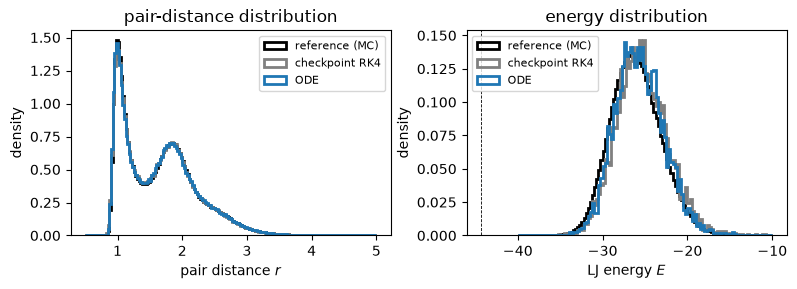

reference (MC)    <E> =  -26.066   std(E) =  2.970   min =  -39.367
checkpoint RK4    <E> =  -25.380   std(E) =  3.041   min =  -35.085
ODE               <E> =  -25.673   std(E) =  2.864   min =  -33.974


In [27]:
series = [(x1.cpu(),             "reference (MC)", "k"),
          (gen_ckpt.cpu(),       "checkpoint RK4", "gray"),
          (gen_ode.cpu(),        "ODE",            "C0")]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
rbins = np.linspace(0.5, 5.0, 181)
for x, lbl, c in series:
    ax[0].hist(pair_distances(x), bins=rbins, density=True, histtype="step", lw=2,
               label=lbl, color=c)
ax[0].set_xlabel(r"pair distance $r$"); ax[0].set_ylabel("density")
ax[0].set_title("pair-distance distribution"); ax[0].legend(fontsize=8)

ebins = np.linspace(-40, -10, 121)
for x, lbl, c in series:
    ax[1].hist(energy(x), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].axvline(-44.327, c="k", lw=0.6, ls="--")
ax[1].set_xlabel("LJ energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for x, lbl, _ in series:
    e = energy(x)
    print(f"{lbl:16s}  <E> = {e.mean():+8.3f}   std(E) = {e.std():6.3f}   min = {e.min():+8.3f}")

### 5. Entropy estimates

In [31]:

torch.manual_seed(4)
n_batches = 1000
zdots, divs = [], []
for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1_sample = x1[idx]
    x0 = sample_prior(batch_size, device=device)
    x0, x1_sample = equivariant_ot_couple(x0, x1_sample)
    zdots.append(model.entropy_estimate(x1_sample,x0,method="zdot").mean().cpu().numpy())
    divs.append(model.entropy_estimate(x1_sample,x0,method="div").mean().cpu().numpy())



In [32]:
# copied over from our thermodynamic integration
print(f"entropy estimate (TI)    : {-34.1654956596782:+.3f} ± {0.018956693545144593:.3f}")

print("Batch Entropy Estimates:")

strap = scipy.stats.bootstrap((zdots,),np.mean,method='percentile')
err_zdot = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
print(f"b*z/gamma : {np.mean(zdots):.3f} ± {err_zdot:.3f}")

strap = scipy.stats.bootstrap((divs,),np.mean,method='percentile')
err_div = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
print(f"div(b)    : {np.mean(divs):.3f} ± {err_div:.3f}")


entropy estimate (TI)    : -34.165 ± 0.019
Batch Entropy Estimates:
b*z/gamma : -34.142 ± 0.110
div(b)    : -34.070 ± 0.099


In [33]:
# Running entropy change along many ODE paths.
torch.manual_seed(5)
x0 = sample_prior(5_000, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=50, return_traj=True, entropy='div')
ts_c, ent_c_div = ts.cpu().numpy(), ent_traj.cpu().numpy()


torch.manual_seed(6)
x0 = sample_prior(5_000, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=50, return_traj=True, entropy='dot')
ts_c, ent_c_dot = ts.cpu().numpy(), ent_traj.cpu().numpy()

In [34]:
# copied over from our thermodynamic integration
print(f"entropy estimate (TI)    : {-34.1654956596782:+.3f} ± {0.018956693545144593:.3f}")


print("Flow Entropy Estimates:")

strap = scipy.stats.bootstrap((ent_c_dot[-1],),np.mean,method='percentile')
err_dot = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
print(f"b*s      : {np.mean(ent_c_dot[-1]):.3f} ± {err_dot:.3f}")

strap = scipy.stats.bootstrap((ent_c_div[-1],),np.mean,method='percentile')
err_div = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
print(f"div(b)   : {np.mean(ent_c_div[-1]):.3f} ± {err_div:.3f}")


entropy estimate (TI)    : -34.165 ± 0.019
Flow Entropy Estimates:
b*s      : -33.865 ± 0.200
div(b)   : -33.714 ± 0.106


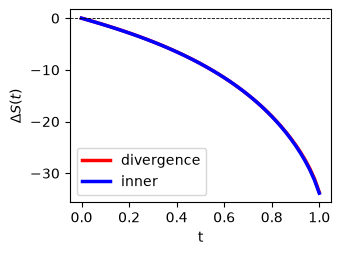

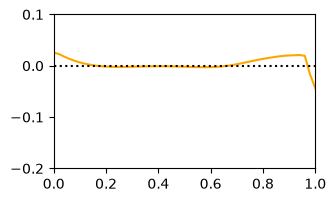

In [35]:
fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.plot(ts_c, ent_c_div.mean(axis=1), c="red", lw=2.5, label="divergence")
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="blue", lw=2.5, label="inner")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.legend()
plt.show()

div_mean = ent_c_div.mean(axis=1)
dot_mean = ent_c_dot.mean(axis=1)

dsdt_div = np.gradient(div_mean)
dsdt_dot = np.gradient(dot_mean)
err = (dsdt_dot - dsdt_div)/dsdt_div

fig, ax = plt.subplots(figsize=(3.375, 2))
plt.plot(ts_c,err,'-',color='orange')
plt.axhline(0,-1,1,color='k',linestyle=':',lw=1.5)
plt.ylim(-0.2,0.1)
plt.xlim(0,1)
plt.show()
